In [1]:
import pandas as pd
import numpy as np

In [3]:
treino = pd.read_csv("../dados/treino.csv")
teste1 = pd.read_csv("../dados/teste1.csv")
teste2 = pd.read_csv("../dados/teste2.csv")

C:\Users\joaov\AppData\Local\Temp\ipykernel_9724\458128174.py:1: DtypeWarning: Columns (0: EXTRAPU1_N, 1: EXTRAPUL_O, 2: AGRAVOUTDE, 3: OUTRAS_DES, 4: BAC_APOS_6) have mixed types. Specify dtype option on import or set low_memory=False.
  treino = pd.read_csv("../dados/treino.csv")


In [4]:
treino.info()

treino.head()

treino["ltfu"].value_counts()

treino.isnull().mean()*100

<class 'pandas.DataFrame'>
RangeIndex: 562632 entries, 0 to 562631
Columns: 101 entries, TP_NOT to ltfu
dtypes: float64(71), int64(22), object(4), str(4)
memory usage: 433.5+ MB


TP_NOT         0.000000
ID_AGRAVO      0.000000
DT_NOTIFIC     0.000000
NU_ANO         0.000000
SG_UF_NOT      0.000000
                ...    
MUN_TRANSF    98.526923
idade_unid     0.000000
idade_val      0.000000
idade_anos     0.000000
ltfu           0.000000
Length: 101, dtype: float64

In [5]:
print("Treino:", treino.shape)
print("Teste 1:", teste1.shape)
print("Teste 2:", teste2.shape)

Treino: (562632, 101)
Teste 1: (631, 101)
Teste 2: (631, 101)


In [6]:
treino.columns.tolist()

['TP_NOT',
 'ID_AGRAVO',
 'DT_NOTIFIC',
 'NU_ANO',
 'SG_UF_NOT',
 'ID_MUNICIP',
 'ID_REGIONA',
 'DT_DIAG',
 'ANO_NASC',
 'NU_IDADE_N',
 'CS_SEXO',
 'CS_GESTANT',
 'CS_RACA',
 'CS_ESCOL_N',
 'SG_UF',
 'ID_MN_RESI',
 'ID_RG_RESI',
 'ID_PAIS',
 'NDUPLIC_N',
 'IN_VINCULA',
 'DT_DIGITA',
 'DT_TRANSUS',
 'DT_TRANSDM',
 'DT_TRANSSM',
 'DT_TRANSRM',
 'DT_TRANSRS',
 'DT_TRANSSE',
 'CS_FLXRET',
 'FLXRECEBI',
 'MIGRADO_W',
 'ID_OCUPA_N',
 'TRATAMENTO',
 'INSTITUCIO',
 'RAIOX_TORA',
 'TESTE_TUBE',
 'FORMA',
 'EXTRAPU1_N',
 'EXTRAPU2_N',
 'EXTRAPUL_O',
 'AGRAVAIDS',
 'AGRAVALCOO',
 'AGRAVDIABE',
 'AGRAVDOENC',
 'AGRAVOUTRA',
 'AGRAVOUTDE',
 'BACILOSC_E',
 'BACILOS_E2',
 'BACILOSC_O',
 'CULTURA_ES',
 'CULTURA_OU',
 'HIV',
 'HISTOPATOL',
 'DT_INIC_TR',
 'RIFAMPICIN',
 'ISONIAZIDA',
 'ETAMBUTOL',
 'ESTREPTOMI',
 'PIRAZINAMI',
 'ETIONAMIDA',
 'OUTRAS',
 'OUTRAS_DES',
 'TRAT_SUPER',
 'NU_CONTATO',
 'DOENCA_TRA',
 'SG_UF_AT',
 'ID_MUNIC_A',
 'DT_NOTI_AT',
 'SG_UF_2',
 'ID_MUNIC_2',
 'BACILOSC_1',
 'BACIL

In [11]:
treino.dtypes.value_counts()

float64    71
int64      22
str         4
object      4
Name: count, dtype: int64

In [ ]:
for coluna in treino.columns:
    print(coluna, "-", treino[coluna].dtype)

TP_NOT - int64
ID_AGRAVO - str
DT_NOTIFIC - str
NU_ANO - int64
SG_UF_NOT - int64
ID_MUNICIP - int64
ID_REGIONA - float64
DT_DIAG - int64
ANO_NASC - float64
NU_IDADE_N - int64
CS_SEXO - str
CS_GESTANT - int64
CS_RACA - float64
CS_ESCOL_N - float64
SG_UF - int64
ID_MN_RESI - int64
ID_RG_RESI - float64
ID_PAIS - float64
NDUPLIC_N - float64
IN_VINCULA - float64
DT_DIGITA - float64
DT_TRANSUS - float64
DT_TRANSDM - float64
DT_TRANSSM - float64
DT_TRANSRM - float64
DT_TRANSRS - float64
DT_TRANSSE - float64
CS_FLXRET - float64
FLXRECEBI - float64
MIGRADO_W - float64
ID_OCUPA_N - float64
TRATAMENTO - int64
INSTITUCIO - float64
RAIOX_TORA - float64
TESTE_TUBE - float64
FORMA - int64
EXTRAPU1_N - object
EXTRAPU2_N - float64
EXTRAPUL_O - object
AGRAVAIDS - float64
AGRAVALCOO - float64
AGRAVDIABE - float64
AGRAVDOENC - float64
AGRAVOUTRA - float64
AGRAVOUTDE - str
BACILOSC_E - int64
BACILOS_E2 - float64
BACILOSC_O - float64
CULTURA_ES - int64
CULTURA_OU - float64
HIV - float64
HISTOPATOL - float64

In [12]:
treino["ltfu"].value_counts()

ltfu
0    453378
1    109254
Name: count, dtype: int64

In [ ]:
treino["ltfu"].value_counts(normalize=True) * 100

ltfu
0    80.581624
1    19.418376
Name: proportion, dtype: float64

In [13]:
missing_percentual = treino.isnull().mean().sort_values(ascending=False) * 100

missing_percentual.head(30)

FLXRECEBI     100.000000
CS_FLXRET     100.000000
DT_TRANSRM    100.000000
DT_TRANSDM     98.984238
DT_TRANSRS     98.698794
MUN_TRANSF     98.526923
UF_TRANSF      97.909646
AGRAVOUTDE     97.213454
DT_TRANSUS     96.973866
EXTRAPUL_O     95.906738
SITUA_12_M     87.160702
OUTRAS_DES     83.644016
ID_OCUPA_N     81.763746
DT_TRANSSE     77.163759
DT_MUDANCA     67.166638
EXTRAPU2_N     67.166638
MIGRADO_W      67.166638
ESTREPTOMI     67.166460
ETAMBUTOL      67.166283
ETIONAMIDA     67.166283
PIRAZINAMI     67.166283
ISONIAZIDA     67.166283
RIFAMPICIN     67.166283
OUTRAS         67.166283
SITUA_9_M      67.166105
TESTE_TUBE     67.165750
DOENCA_TRA     67.165750
INSTITUCIO     67.165572
BACILOS_E2     67.165394
TRANSF         65.567547
dtype: float64

In [14]:
colunas_muitos_ausentes = missing_percentual[missing_percentual > 70]

colunas_muitos_ausentes

FLXRECEBI     100.000000
CS_FLXRET     100.000000
DT_TRANSRM    100.000000
DT_TRANSDM     98.984238
DT_TRANSRS     98.698794
MUN_TRANSF     98.526923
UF_TRANSF      97.909646
AGRAVOUTDE     97.213454
DT_TRANSUS     96.973866
EXTRAPUL_O     95.906738
SITUA_12_M     87.160702
OUTRAS_DES     83.644016
ID_OCUPA_N     81.763746
DT_TRANSSE     77.163759
dtype: float64

In [15]:
valores_unicos = treino.nunique(dropna=False).sort_values()

valores_unicos.head(30)

TP_NOT        1
DT_TRANSRM    1
FLXRECEBI     1
CS_FLXRET     1
FORMA         1
idade_unid    1
DT_MUDANCA    2
ID_AGRAVO     2
POP_IMIG      2
ltfu          2
SITUA_ENCE    2
POP_RUA       2
POP_SAUDE     2
POP_LIBER     2
CS_GESTANT    3
CS_SEXO       3
EXTRAPU2_N    3
EXTRAPUL_O    4
MIGRADO_W     4
IN_VINCULA    4
BACILOSC_E    4
ETIONAMIDA    5
PIRAZINAMI    5
ESTREPTOMI    5
CULTURA_ES    5
ETAMBUTOL     5
ISONIAZIDA    5
RIFAMPICIN    5
OUTRAS        5
NDUPLIC_N     5
dtype: int64

In [16]:
colunas_constantes = valores_unicos[valores_unicos <= 1]

colunas_constantes

TP_NOT        1
DT_TRANSRM    1
FLXRECEBI     1
CS_FLXRET     1
FORMA         1
idade_unid    1
dtype: int64

In [17]:
for coluna in treino.columns:
    qtd_unicos = treino[coluna].nunique(dropna=False)
    
    if qtd_unicos <= 10:
        print(f"{coluna}: {qtd_unicos} valores únicos")

TP_NOT: 1 valores únicos
ID_AGRAVO: 2 valores únicos
CS_SEXO: 3 valores únicos
CS_GESTANT: 3 valores únicos
CS_RACA: 9 valores únicos
ID_PAIS: 9 valores únicos
NDUPLIC_N: 5 valores únicos
IN_VINCULA: 4 valores únicos
DT_TRANSRM: 1 valores únicos
CS_FLXRET: 1 valores únicos
FLXRECEBI: 1 valores únicos
MIGRADO_W: 4 valores únicos
TRATAMENTO: 5 valores únicos
INSTITUCIO: 9 valores únicos
RAIOX_TORA: 7 valores únicos
TESTE_TUBE: 7 valores únicos
FORMA: 1 valores únicos
EXTRAPU1_N: 8 valores únicos
EXTRAPU2_N: 3 valores únicos
EXTRAPUL_O: 4 valores únicos
AGRAVAIDS: 6 valores únicos
AGRAVALCOO: 5 valores únicos
AGRAVDIABE: 6 valores únicos
AGRAVDOENC: 5 valores únicos
AGRAVOUTRA: 5 valores únicos
BACILOSC_E: 4 valores únicos
BACILOS_E2: 6 valores únicos
BACILOSC_O: 6 valores únicos
CULTURA_ES: 5 valores únicos
CULTURA_OU: 7 valores únicos
HIV: 6 valores únicos
HISTOPATOL: 9 valores únicos
RIFAMPICIN: 5 valores únicos
ISONIAZIDA: 5 valores únicos
ETAMBUTOL: 5 valores únicos
ESTREPTOMI: 5 val

In [18]:
variaveis_interesse = [
    "CS_SEXO",
    "CS_RACA",
    "HIV",
    "AGRAVALCOO",
    "AGRAVDROGA",
    "POP_RUA",
    "TRATAMENTO"
]

for coluna in variaveis_interesse:
    if coluna in treino.columns:
        print("\n", coluna)
        print(treino[coluna].value_counts(dropna=False))


 CS_SEXO
CS_SEXO
M    403713
F    158878
I        41
Name: count, dtype: int64

 CS_RACA
CS_RACA
4.0    282841
1.0    160248
2.0     79031
9.0     22812
5.0      5149
3.0      4681
NaN      4235
0.0      3634
6.0         1
Name: count, dtype: int64

 HIV
HIV
2.0    442167
4.0     71535
1.0     44798
3.0      3046
NaN       755
0.0       331
Name: count, dtype: int64

 AGRAVALCOO
AGRAVALCOO
2.0    425474
1.0    114616
9.0     18985
NaN      2527
0.0      1030
Name: count, dtype: int64

 AGRAVDROGA
AGRAVDROGA
2.0    435183
1.0    101859
9.0     21500
NaN      2409
0.0      1681
Name: count, dtype: int64

 POP_RUA
POP_RUA
2    540356
1     22276
Name: count, dtype: int64

 TRATAMENTO
TRATAMENTO
1    449548
3     58090
2     43245
5     10595
4      1154
Name: count, dtype: int64


In [19]:
colunas_data = [coluna for coluna in treino.columns if "DT_" in coluna]

colunas_data

['DT_NOTIFIC',
 'DT_DIAG',
 'DT_DIGITA',
 'DT_TRANSUS',
 'DT_TRANSDM',
 'DT_TRANSSM',
 'DT_TRANSRM',
 'DT_TRANSRS',
 'DT_TRANSSE',
 'DT_INIC_TR',
 'DT_NOTI_AT',
 'DT_MUDANCA',
 'DT_ENCERRA']

In [20]:
for coluna in colunas_data:
    print("\n", coluna)
    print(treino[coluna].head())
    print("Tipo:", treino[coluna].dtype)


 DT_NOTIFIC
0    2003-03-17
1    2005-06-10
2    2006-02-02
3    2006-01-24
4    2006-02-22
Name: DT_NOTIFIC, dtype: str
Tipo: str

 DT_DIAG
0    20030317
1    20050610
2    20051220
3    20051117
4    20051229
Name: DT_DIAG, dtype: int64
Tipo: int64

 DT_DIGITA
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: DT_DIGITA, dtype: float64
Tipo: float64

 DT_TRANSUS
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: DT_TRANSUS, dtype: float64
Tipo: float64

 DT_TRANSDM
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: DT_TRANSDM, dtype: float64
Tipo: float64

 DT_TRANSSM
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: DT_TRANSSM, dtype: float64
Tipo: float64

 DT_TRANSRM
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: DT_TRANSRM, dtype: float64
Tipo: float64

 DT_TRANSRS
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: DT_TRANSRS, dtype: float64
Tipo: float64

 DT_TRANSSE
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: DT_TRANSSE, dtype: float64
Tipo: float64

 DT_INIC_TR
0    20030317.0
1    20050610.0
2    

In [21]:
colunas_situacao = [
    coluna for coluna in treino.columns
    if "SITUA" in coluna or "ENCE" in coluna or "ENCERRA" in coluna
]

colunas_situacao

['SITUA_9_M', 'SITUA_12_M', 'SITUA_ENCE', 'DT_ENCERRA']

In [22]:
colunas_possivel_vazamento = [
    "SITUA_ENCE",
    "DT_ENCERRA",
    "DT_MUDANCA",
    "SITUA_9_M",
    "SITUA_12_M",
    "TRATSUP_AT",
    "DOENCA_TRA"
]

for coluna in colunas_possivel_vazamento:
    print(coluna, "-", coluna in treino.columns)

SITUA_ENCE - True
DT_ENCERRA - True
DT_MUDANCA - True
SITUA_9_M - True
SITUA_12_M - True
TRATSUP_AT - True
DOENCA_TRA - True


In [23]:
for coluna in colunas_possivel_vazamento:
    if coluna in treino.columns:
        print("\n", coluna)
        print(treino[coluna].value_counts(dropna=False).head(20))


 SITUA_ENCE
SITUA_ENCE
1    453378
2    109254
Name: count, dtype: int64

 DT_ENCERRA
DT_ENCERRA
NaN           26897
20231130.0      427
20240930.0      403
20200930.0      386
20230228.0      379
20240430.0      364
20220930.0      360
20221130.0      352
20210930.0      350
20231220.0      337
20230630.0      337
20231030.0      336
20240830.0      326
20220630.0      325
20240220.0      325
20190930.0      323
20200430.0      323
20240229.0      322
20190430.0      320
20200630.0      317
Name: count, dtype: int64

 DT_MUDANCA
DT_MUDANCA
NaN           377901
18991230.0    184731
Name: count, dtype: int64

 SITUA_9_M
SITUA_9_M
NaN     377898
0.0     159001
1.0      19988
2.0       3695
12.0      1665
5.0        125
9.0        123
6.0         89
7.0         17
11.0        11
10.0         7
4.0          5
3.0          4
13.0         4
Name: count, dtype: int64

 SITUA_12_M
SITUA_12_M
NaN     490394
0.0      49211
1.0      19727
2.0       3172
9.0        122
5.0          2
3.0         

In [24]:
colunas_baciloscopia = [
    coluna for coluna in treino.columns
    if "BACIL" in coluna
]

colunas_baciloscopia

['BACILOSC_E',
 'BACILOS_E2',
 'BACILOSC_O',
 'BACILOSC_1',
 'BACILOSC_2',
 'BACILOSC_3',
 'BACILOSC_4',
 'BACILOSC_5',
 'BACILOSC_6']

In [25]:
for coluna in colunas_baciloscopia:
    print("\n", coluna)
    print(treino[coluna].value_counts(dropna=False).head(20))


 BACILOSC_E
BACILOSC_E
1    330615
3    132541
2     89036
4     10440
Name: count, dtype: int64

 BACILOS_E2
BACILOS_E2
NaN    377894
0.0    176544
1.0      4139
3.0      2273
2.0      1700
9.0        82
Name: count, dtype: int64

 BACILOSC_O
BACILOSC_O
NaN    300671
0.0    141942
3.0    115666
2.0      2409
1.0      1872
9.0        72
Name: count, dtype: int64

 BACILOSC_1
BACILOSC_1
3.0    188520
1.0    141247
2.0    130061
NaN     64934
0.0     36633
4.0      1214
9.0        23
Name: count, dtype: int64

 BACILOSC_2
BACILOSC_2
3.0    220205
2.0    196350
NaN     78404
1.0     34649
0.0     31584
4.0      1415
9.0        25
Name: count, dtype: int64

 BACILOSC_3
BACILOSC_3
3.0    235233
2.0    185139
NaN     91091
0.0     36456
1.0     13021
4.0      1667
9.0        25
Name: count, dtype: int64

 BACILOSC_4
BACILOSC_4
3.0    231928
2.0    179229
NaN    102608
0.0     40726
1.0      6237
4.0      1878
9.0        26
Name: count, dtype: int64

 BACILOSC_5
BACILOSC_5
3.0    229052
2.0 

In [26]:
colunas_numericas = treino.select_dtypes(include=["int64", "float64"]).columns.tolist()

colunas_categoricas = treino.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numéricas:", len(colunas_numericas))
print("Categóricas:", len(colunas_categoricas))

Numéricas: 93
Categóricas: 8


In [27]:
numericas_com_poucos_valores = []

for coluna in colunas_numericas:
    qtd_unicos = treino[coluna].nunique(dropna=False)
    
    if qtd_unicos <= 10:
        numericas_com_poucos_valores.append(coluna)

numericas_com_poucos_valores

['TP_NOT',
 'CS_GESTANT',
 'CS_RACA',
 'ID_PAIS',
 'NDUPLIC_N',
 'IN_VINCULA',
 'DT_TRANSRM',
 'CS_FLXRET',
 'FLXRECEBI',
 'MIGRADO_W',
 'TRATAMENTO',
 'INSTITUCIO',
 'RAIOX_TORA',
 'TESTE_TUBE',
 'FORMA',
 'EXTRAPU2_N',
 'AGRAVAIDS',
 'AGRAVALCOO',
 'AGRAVDIABE',
 'AGRAVDOENC',
 'AGRAVOUTRA',
 'BACILOSC_E',
 'BACILOS_E2',
 'BACILOSC_O',
 'CULTURA_ES',
 'CULTURA_OU',
 'HIV',
 'HISTOPATOL',
 'RIFAMPICIN',
 'ISONIAZIDA',
 'ETAMBUTOL',
 'ESTREPTOMI',
 'PIRAZINAMI',
 'ETIONAMIDA',
 'OUTRAS',
 'TRAT_SUPER',
 'DOENCA_TRA',
 'BACILOSC_1',
 'BACILOSC_2',
 'BACILOSC_3',
 'BACILOSC_4',
 'BACILOSC_5',
 'BACILOSC_6',
 'TRATSUP_AT',
 'DT_MUDANCA',
 'SITUA_12_M',
 'SITUA_ENCE',
 'POP_LIBER',
 'POP_RUA',
 'POP_SAUDE',
 'POP_IMIG',
 'BENEF_GOV',
 'AGRAVDROGA',
 'AGRAVTABAC',
 'TEST_MOLEC',
 'TEST_SENSI',
 'ANT_RETRO',
 'TRANSF',
 'idade_unid',
 'ltfu']

In [28]:
for coluna in treino.columns:
    tipos = treino[coluna].map(type).value_counts()
    
    if len(tipos) > 1:
        print("\nCOLUNA:", coluna)
        print(tipos)


COLUNA: EXTRAPU1_N
EXTRAPU1_N
<class 'str'>      332883
<class 'int'>      180224
<class 'float'>     49525
Name: count, dtype: int64

COLUNA: EXTRAPUL_O
EXTRAPUL_O
<class 'float'>    539714
<class 'str'>       22918
Name: count, dtype: int64

COLUNA: AGRAVOUTDE
AGRAVOUTDE
<class 'float'>    546954
<class 'str'>       15678
Name: count, dtype: int64

COLUNA: OUTRAS_DES
OUTRAS_DES
<class 'float'>    479580
<class 'int'>       81920
<class 'str'>        1132
Name: count, dtype: int64

COLUNA: BAC_APOS_6
BAC_APOS_6
<class 'float'>    365000
<class 'int'>      180224
<class 'str'>       17408
Name: count, dtype: int64


In [29]:
if "EXTRAPU1_N" in treino.columns:
    treino["EXTRAPU1_N"].map(type).value_counts()

In [30]:
if "EXTRAPU1_N" in treino.columns:
    treino["EXTRAPU1_N"].value_counts(dropna=False).head(30)

In [31]:
resumo_variaveis = pd.DataFrame({
    "tipo": treino.dtypes,
    "valores_unicos": treino.nunique(dropna=False),
    "missing_%": treino.isnull().mean() * 100
})

resumo_variaveis = resumo_variaveis.sort_values("missing_%", ascending=False)

resumo_variaveis.head(50)

,tipo,valores_unicos,missing_%
FLXRECEBI,float64,1,100.000000
CS_FLXRET,float64,1,100.000000
DT_TRANSRM,float64,1,100.000000
DT_TRANSDM,float64,997,98.984238
DT_TRANSRS,float64,1145,98.698794
MUN_TRANSF,float64,29,98.526923
UF_TRANSF,float64,29,97.909646
AGRAVOUTDE,str,5215,97.213454
DT_TRANSUS,float64,1668,96.973866
EXTRAPUL_O,object,4,95.906738


In [32]:
treino_limpo = treino.copy()
teste1_limpo = teste1.copy()
teste2_limpo = teste2.copy()

In [168]:
colunas_leakage = [
    "SITUA_ENCE",
    "DT_ENCERRA",
    "DT_MUDANCA",
    "SITUA_9_M",
    "SITUA_12_M",
    "TRATSUP_AT",
    "DOENCA_TRA",
    "BACILOSC_1",
    "BACILOSC_2",
    "BACILOSC_3",
    "BACILOSC_4",
    "BACILOSC_5",
    "BACILOSC_6",
    "BAC_APOS_6",
    "NU_COMU_EX",
    "TRAT_SUPER",
    "SG_UF_AT",
    "SG_UF_2",
    "TRANSF",
    "NDUPLIC_N",
    "IN_VINCULA"
]

In [169]:
treino_limpo = treino_limpo.drop(columns=colunas_leakage, errors="ignore")
teste1_limpo = teste1_limpo.drop(columns=colunas_leakage, errors="ignore")
teste2_limpo = teste2_limpo.drop(columns=colunas_leakage, errors="ignore")

In [170]:
colunas_constantes = [
    coluna for coluna in treino_limpo.columns
    if treino_limpo[coluna].nunique(dropna=False) <= 1
]

colunas_constantes

[]

In [171]:
treino_limpo = treino_limpo.drop(columns=colunas_constantes, errors="ignore")
teste1_limpo = teste1_limpo.drop(columns=colunas_constantes, errors="ignore")
teste2_limpo = teste2_limpo.drop(columns=colunas_constantes, errors="ignore")

In [172]:
percentual_ausentes = treino_limpo.isnull().mean() * 100

colunas_muitos_ausentes = percentual_ausentes[percentual_ausentes > 70].index.tolist()

colunas_muitos_ausentes

[]

In [228]:
treino_limpo = treino_limpo.drop(columns=colunas_muitos_ausentes, errors="ignore")
teste1_limpo = teste1_limpo.drop(columns=colunas_muitos_ausentes, errors="ignore")
teste2_limpo = teste2_limpo.drop(columns=colunas_muitos_ausentes, errors="ignore")

In [ ]:
colunas_datas_remover = [
    "DT_NOTIFIC",
    "DT_DIAG",
    "DT_DIGITA",
    "DT_TRANSSM",
    "DT_INIC_TR",
    "DT_NOTI_AT"
]

treino_limpo = treino_limpo.drop(columns=colunas_datas_remover, errors="ignore")
teste1_limpo = teste1_limpo.drop(columns=colunas_datas_remover, errors="ignore")
teste2_limpo = teste2_limpo.drop(columns=colunas_datas_remover, errors="ignore")

In [226]:
colunas_identificadores = [
    "ID_MUNICIP",
    "ID_REGIONA",
    "ID_MN_RESI",
    "ID_RG_RESI",
    "ID_MUNIC_A",
    "ID_MUNIC_2"
]

treino_limpo = treino_limpo.drop(columns=colunas_identificadores, errors="ignore")
teste1_limpo = teste1_limpo.drop(columns=colunas_identificadores, errors="ignore")
teste2_limpo = teste2_limpo.drop(columns=colunas_identificadores, errors="ignore")

In [225]:
colunas_redundantes = [
    "ANO_NASC",
    "NU_IDADE_N"
]

treino_limpo = treino_limpo.drop(columns=colunas_redundantes, errors="ignore")
teste1_limpo = teste1_limpo.drop(columns=colunas_redundantes, errors="ignore")
teste2_limpo = teste2_limpo.drop(columns=colunas_redundantes, errors="ignore")

In [232]:
colunas_importancia_zero = [
    "BACILOS_E2",
    "ID_PAIS",
    "NU_ANO",
    "ID_AGRAVO",
    "EXTRAPU2_N",
    "TESTE_TUBE",
    "EXTRAPU1_N",
    "MIGRADO_W",
    "INSTITUCIO",
    "ISONIAZIDA",
    "RIFAMPICIN",
    "ETAMBUTOL",
    "POP_SAUDE",
    "OUTRAS",
    "ETIONAMIDA",
    "ESTREPTOMI",
    "PIRAZINAMI"
]

treino_limpo = treino_limpo.drop(columns=colunas_importancia_zero, errors="ignore")
teste1_limpo = teste1_limpo.drop(columns=colunas_importancia_zero, errors="ignore")
teste2_limpo = teste2_limpo.drop(columns=colunas_importancia_zero, errors="ignore")

In [233]:
X_treino = treino_limpo.drop(columns=["ltfu"])
y_treino = treino_limpo["ltfu"]

X_teste1 = teste1_limpo.drop(columns=["ltfu"])
y_teste1 = teste1_limpo["ltfu"]

X_teste2 = teste2_limpo.drop(columns=["ltfu"])
y_teste2 = teste2_limpo["ltfu"]

In [234]:
colunas_comuns = X_treino.columns.intersection(X_teste1.columns).intersection(X_teste2.columns)

X_treino = X_treino[colunas_comuns]
X_teste1 = X_teste1[colunas_comuns]
X_teste2 = X_teste2[colunas_comuns]

print(X_treino.shape)
print(X_teste1.shape)
print(X_teste2.shape)

(562632, 32)
(631, 32)
(631, 32)


In [235]:
colunas_categoricas_manuais = [
    "ID_AGRAVO",
    "CS_SEXO",
    "CS_GESTANT",
    "CS_RACA",
    "ID_PAIS",
    "IN_VINCULA",
    "MIGRADO_W",
    "TRATAMENTO",
    "INSTITUCIO",
    "RAIOX_TORA",
    "TESTE_TUBE",
    "EXTRAPU1_N",
    "EXTRAPU2_N",
    "AGRAVAIDS",
    "AGRAVALCOO",
    "AGRAVDIABE",
    "AGRAVOUTRA",
    "BACILOSC_E",
    "BACILOSC_O",
    "CULTURA_ES",
    "CULTURA_OU",
    "HIV",
    "HISTOPATOL",
    "RIFAMPICIN",
    "ISONIAZIDA",
    "ETAMBUTOL",
    "ESTREPTOMI",
    "PIRAZINAMI",
    "ETIONAMIDA",
    "OUTRAS",
    "TRAT_SUPER",
    "POP_LIBER",
    "POP_RUA",
    "POP_SAUDE",
    "POP_IMIG",
    "BENEF_GOV",
    "AGRAVDROGA",
    "AGRAVTABAC",
    "TEST_MOLEC",
    "TEST_SENSI",
    "ANT_RETRO"
]

In [236]:
colunas_categoricas = [
    coluna for coluna in colunas_categoricas_manuais
    if coluna in X_treino.columns
]

colunas_categoricas += X_treino.select_dtypes(
    include=["object", "string"]
).columns.tolist()

colunas_categoricas = list(set(colunas_categoricas))

In [237]:
for coluna in colunas_categoricas:
    X_treino[coluna] = X_treino[coluna].astype(str)
    X_teste1[coluna] = X_teste1[coluna].astype(str)
    X_teste2[coluna] = X_teste2[coluna].astype(str)

In [246]:
colunas_categoricas = [
    col for col in colunas_categoricas
    if col in X_treino.columns
]

colunas_numericas = [
    col for col in X_treino.columns
    if col not in colunas_categoricas
]

print("Numéricas:", len(colunas_numericas))
print("Categóricas:", len(colunas_categoricas))

Numéricas: 8
Categóricas: 24


In [238]:
for coluna in colunas_leakage:
    print(coluna, "-", coluna in X_treino.columns)

SITUA_ENCE - False
DT_ENCERRA - False
DT_MUDANCA - False
SITUA_9_M - False
SITUA_12_M - False
TRATSUP_AT - False
DOENCA_TRA - False
BACILOSC_1 - False
BACILOSC_2 - False
BACILOSC_3 - False
BACILOSC_4 - False
BACILOSC_5 - False
BACILOSC_6 - False
BAC_APOS_6 - False
NU_COMU_EX - False
TRAT_SUPER - False
SG_UF_AT - False
SG_UF_2 - False
TRANSF - False
NDUPLIC_N - False
IN_VINCULA - False


In [247]:
print("X_treino:", X_treino.shape)
print("X_teste1:", X_teste1.shape)
print("X_teste2:", X_teste2.shape)

print("y_treino:", y_treino.shape)
print("y_teste1:", y_teste1.shape)
print("y_teste2:", y_teste2.shape)

X_treino: (562632, 32)
X_teste1: (631, 32)
X_teste2: (631, 32)
y_treino: (562632,)
y_teste1: (631,)
y_teste2: (631,)


In [240]:
print("Treino:")
print(y_treino.value_counts(normalize=True) * 100)

print("\nTeste 1:")
print(y_teste1.value_counts(normalize=True) * 100)

print("\nTeste 2:")
print(y_teste2.value_counts(normalize=True) * 100)

Treino:
ltfu
0    80.581624
1    19.418376
Name: proportion, dtype: float64

Teste 1:
ltfu
0    56.101426
1    43.898574
Name: proportion, dtype: float64

Teste 2:
ltfu
1    69.413629
0    30.586371
Name: proportion, dtype: float64


In [241]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

In [248]:
tratamento_numerico = Pipeline([
    ("preencher_mediana", SimpleImputer(strategy="median")),
    ("normalizar", RobustScaler())
])

In [249]:
tratamento_categorico = Pipeline([
    ("preencher_frequente", SimpleImputer(strategy="most_frequent")),
    ("codificar", OneHotEncoder(handle_unknown="ignore"))
])

In [250]:
pre_processamento = ColumnTransformer([
    ("numericas", tratamento_numerico, colunas_numericas),
    ("categoricas", tratamento_categorico, colunas_categoricas)
])

In [251]:
modelo_rl = Pipeline([
    ("pre_processamento", pre_processamento),
    ("classificador", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

In [252]:
modelo_rl.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre_processamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['SG_UF_NOT','CS_SEXO','CS_GESTANT',...,'ANT_RETRO','idade_val', 'idade_anos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [253]:
probabilidades_rl = modelo_rl.predict_proba(X_teste1)[:,1]

previsoes_rl = (probabilidades_rl >= 0.50).astype(int)

print(classification_report(y_teste1, previsoes_rl))

print("ROC-AUC:", roc_auc_score(y_teste1, probabilidades_rl))

              precision    recall  f1-score   support

           0       0.81      0.63      0.71       354
           1       0.63      0.81      0.71       277

    accuracy                           0.71       631
   macro avg       0.72      0.72      0.71       631
weighted avg       0.73      0.71      0.71       631

ROC-AUC: 0.8077566338289583


In [254]:
modelo_rf = Pipeline([
    ("pre_processamento", pre_processamento),
    ("classificador", RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

In [255]:
modelo_rf.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre_processamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['SG_UF_NOT','CS_SEXO','CS_GESTANT',...,'ANT_RETRO','idade_val', 'idade_anos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [257]:
probabilidades_rf = modelo_rf.predict_proba(X_teste1)[:,1]

previsoes_rf = (probabilidades_rf >= 0.50).astype(int)

print(classification_report(y_teste1, previsoes_rf))

print("ROC-AUC:", roc_auc_score(y_teste1, probabilidades_rf))

              precision    recall  f1-score   support

           0       0.83      0.66      0.73       354
           1       0.65      0.83      0.73       277

    accuracy                           0.73       631
   macro avg       0.74      0.74      0.73       631
weighted avg       0.75      0.73      0.73       631

ROC-AUC: 0.8134624405963817


In [260]:
import numpy as np
from sklearn.metrics import f1_score

for limiar in np.arange(0.20,0.50,0.02):

    previsoes = (probabilidades_rf >= limiar).astype(int)

    f1 = f1_score(y_teste1, previsoes)

    print(limiar, f1)

0.2 0.6169265033407573
0.22 0.6216216216216216
0.24 0.6307339449541285
0.26 0.63121387283237
0.27999999999999997 0.6384976525821596
0.29999999999999993 0.6482593037214885
0.31999999999999995 0.6567901234567901
0.33999999999999997 0.6742712294043093
0.35999999999999993 0.6744487678339819
0.3799999999999999 0.6870838881491345
0.3999999999999999 0.6954102920723226
0.41999999999999993 0.7050359712230215
0.4399999999999999 0.7147058823529412
0.4599999999999999 0.7177177177177178
0.47999999999999987 0.7191358024691358


In [261]:
for limiar in [0.48, 0.50]:
    
    previsoes = (probabilidades_rf >= limiar).astype(int)
    
    print("\nThreshold:", limiar)
    print(classification_report(y_teste1, previsoes))


Threshold: 0.48
              precision    recall  f1-score   support

           0       0.83      0.61      0.70       354
           1       0.63      0.84      0.72       277

    accuracy                           0.71       631
   macro avg       0.73      0.73      0.71       631
weighted avg       0.74      0.71      0.71       631


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.83      0.66      0.73       354
           1       0.65      0.83      0.73       277

    accuracy                           0.73       631
   macro avg       0.74      0.74      0.73       631
weighted avg       0.75      0.73      0.73       631



In [262]:
limiar_final = 0.50

previsoes_rf = (
    probabilidades_rf >= limiar_final
).astype(int)

print(classification_report(
    y_teste1,
    previsoes_rf
))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_teste1,
        probabilidades_rf
    )
)

              precision    recall  f1-score   support

           0       0.83      0.66      0.73       354
           1       0.65      0.83      0.73       277

    accuracy                           0.73       631
   macro avg       0.74      0.74      0.73       631
weighted avg       0.75      0.73      0.73       631

ROC-AUC: 0.8134624405963817


In [263]:
erros = pd.DataFrame({
    "valor_real": y_teste1,
    "probabilidade": probabilidades_rf,
    "previsao": previsoes_rf
}, index=X_teste1.index)

In [264]:
falsos_positivos = erros[
    (erros["valor_real"] == 0)
    &
    (erros["previsao"] == 1)
]

len(falsos_positivos)

122

In [265]:
falsos_negativos = erros[
    (erros["valor_real"] == 1)
    &
    (erros["previsao"] == 0)
]

len(falsos_negativos)

47

In [266]:
falsos_positivos.head()

,valor_real,probabilidade,previsao
2,0,0.783068,1
3,0,0.888347,1
14,0,0.600373,1
18,0,0.617212,1
20,0,0.583579,1


In [267]:
falsos_negativos.head()

,valor_real,probabilidade,previsao
13,1,0.237922,0
17,1,0.382679,0
32,1,0.347646,0
39,1,0.361308,0
49,1,0.393322,0


In [268]:
import joblib

joblib.dump(
    modelo_rf,
    "../modelo/modelo_abandono_tb.pkl"
)

['../modelo/modelo_abandono_tb.pkl']

In [269]:
from sklearn.inspection import permutation_importance

In [270]:
tamanho_amostra = min(2000, len(X_teste1))

X_teste1_amostra = X_teste1.sample(tamanho_amostra, random_state=42)
y_teste1_amostra = y_teste1.loc[X_teste1_amostra.index]

In [271]:
resultado_permutacao = permutation_importance(
    modelo_rf,
    X_teste1_amostra,
    y_teste1_amostra,
    n_repeats=3,
    random_state=42,
    scoring="roc_auc",
    n_jobs=1
)

In [272]:
importancia_variaveis = pd.DataFrame({
    "variavel": X_teste1.columns,
    "importancia_media": resultado_permutacao.importances_mean,
    "desvio_padrao": resultado_permutacao.importances_std
})

importancia_variaveis = importancia_variaveis.sort_values(
    "importancia_media",
    ascending=False
)

importancia_variaveis.head(20)

,variavel,importancia_media,desvio_padrao
6,TRATAMENTO,0.114855,0.001500
21,POP_LIBER,0.021786,0.001449
25,AGRAVDROGA,0.018836,0.001956
22,POP_RUA,0.015967,0.002685
9,AGRAVALCOO,0.006029,0.002646
31,idade_anos,0.005305,0.003245
30,idade_val,0.003887,0.004676
19,NU_CONTATO,0.003107,0.000912
17,HIV,0.002380,0.003141
7,RAIOX_TORA,0.001715,0.000483


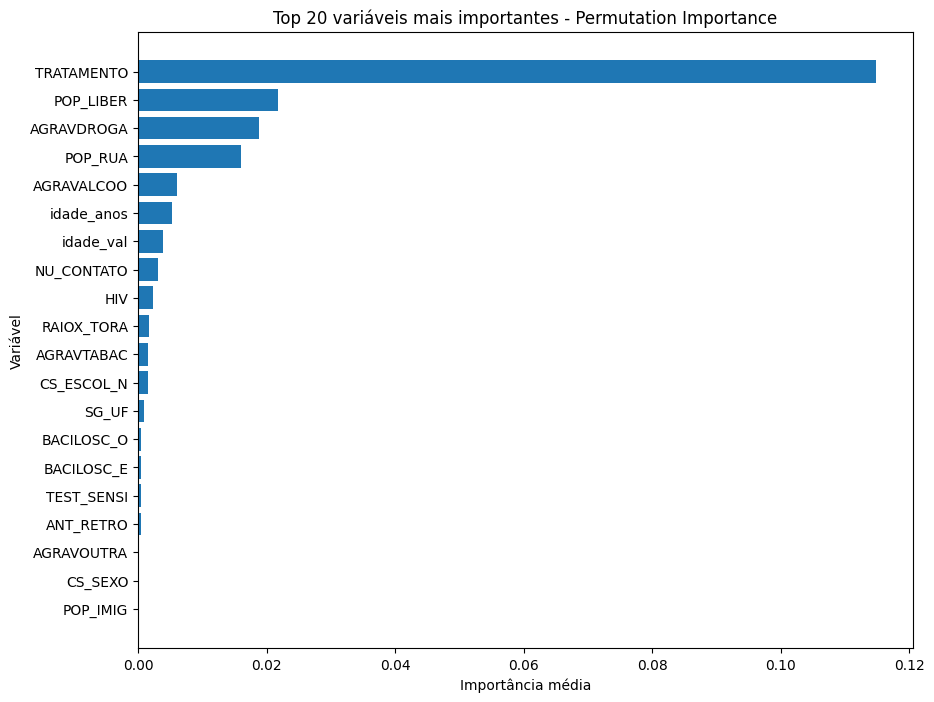

In [273]:
import matplotlib.pyplot as plt

top20_importancia = importancia_variaveis.head(20)

plt.figure(figsize=(10, 8))
plt.barh(
    top20_importancia["variavel"][::-1],
    top20_importancia["importancia_media"][::-1]
)
plt.xlabel("Importância média")
plt.ylabel("Variável")
plt.title("Top 20 variáveis mais importantes - Permutation Importance")
plt.show()

In [274]:
importancia_variaveis.head(20)

,variavel,importancia_media,desvio_padrao
6,TRATAMENTO,0.114855,0.001500
21,POP_LIBER,0.021786,0.001449
25,AGRAVDROGA,0.018836,0.001956
22,POP_RUA,0.015967,0.002685
9,AGRAVALCOO,0.006029,0.002646
31,idade_anos,0.005305,0.003245
30,idade_val,0.003887,0.004676
19,NU_CONTATO,0.003107,0.000912
17,HIV,0.002380,0.003141
7,RAIOX_TORA,0.001715,0.000483


In [277]:
importancia_variaveis[
    importancia_variaveis["importancia_media"] == 0
]

,variavel,importancia_media,desvio_padrao


In [278]:
import shap
import numpy as np
import matplotlib.pyplot as plt

c:\Users\joaov\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [279]:
X_teste_shap = X_teste1.sample(
    min(1000, len(X_teste1)),
    random_state=42
)

In [289]:
X_teste_transformado = (
    modelo_rf.named_steps["pre_processamento"]
    .transform(X_teste_shap)
)

In [290]:
X_teste_transformado = X_teste_transformado.toarray().astype(float)

In [291]:
nomes_variaveis = (
    modelo_rf.named_steps["pre_processamento"]
    .get_feature_names_out()
)

In [292]:
explainer = shap.TreeExplainer(
    modelo_rf.named_steps["classificador"]
)

In [293]:
shap_values = explainer.shap_values(
    X_teste_transformado
)

In [294]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(631, 125, 2)


In [295]:
shap_values_classe1 = shap_values[:, :, 1]

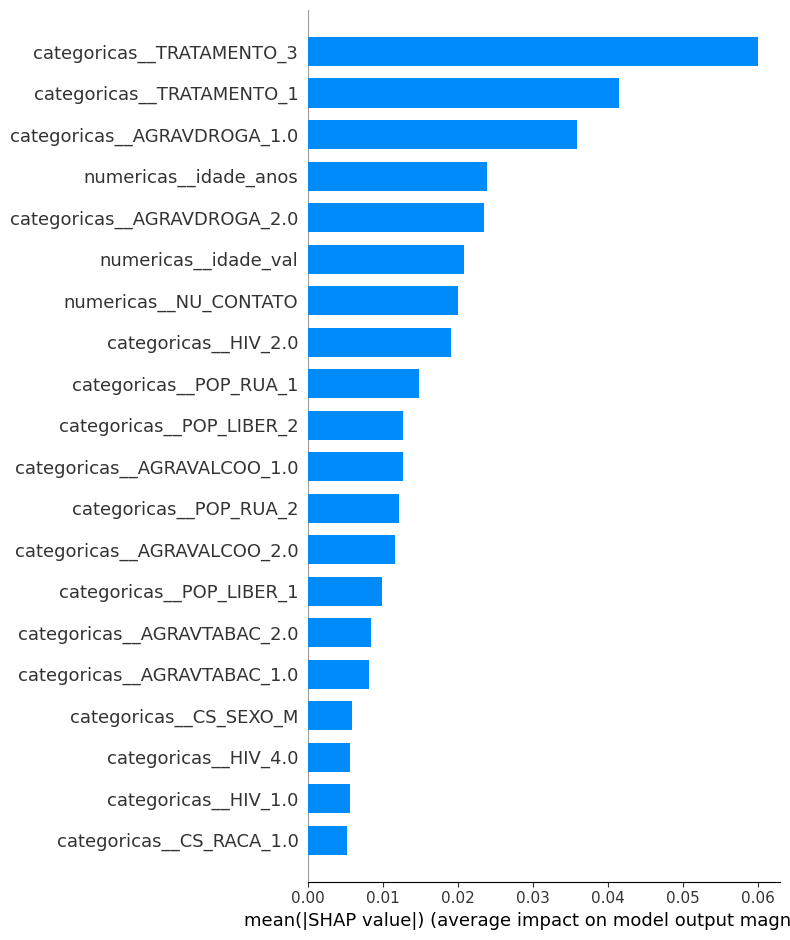

In [297]:
shap.summary_plot(
    shap_values_classe1,
    X_teste_transformado,
    feature_names=nomes_variaveis,
    plot_type="bar"
)

In [304]:
paciente_baixo_risco = X_teste1.iloc[[0]].copy()

paciente_baixo_risco["TRATAMENTO"] = "1"
paciente_baixo_risco["AGRAVDROGA"] = "2.0"
paciente_baixo_risco["AGRAVALCOO"] = "2.0"
paciente_baixo_risco["HIV"] = "2.0"
paciente_baixo_risco["POP_RUA"] = "2"
paciente_baixo_risco["POP_LIBER"] = "2"    

In [305]:
paciente_medio_risco = paciente_baixo_risco.copy()
paciente_medio_risco["HIV"] = "1.0"
paciente_medio_risco["AGRAVALCOO"] = "1.0"  

In [306]:
paciente_alto_risco = paciente_baixo_risco.copy()
paciente_alto_risco["TRATAMENTO"] = "3"
paciente_alto_risco["AGRAVDROGA"] = "1.0"
paciente_alto_risco["AGRAVALCOO"] = "1.0"
paciente_alto_risco["HIV"] = "1.0"
paciente_alto_risco["POP_RUA"] = "1"
paciente_alto_risco["POP_LIBER"] = "1"    

In [307]:
print(
    "Baixo risco:",
    modelo_rf.predict_proba(paciente_baixo_risco)[0,1]
)

print(
    "Médio risco:",
    modelo_rf.predict_proba(paciente_medio_risco)[0,1]
)

print(
    "Alto risco:",
    modelo_rf.predict_proba(paciente_alto_risco)[0,1]
)

Baixo risco: 0.5428125672296268
Médio risco: 0.622627549029792
Alto risco: 0.850123100958309


In [310]:
paciente_alto_transformado = (
    modelo_rf.named_steps["pre_processamento"]
    .transform(paciente_alto_risco)
)

paciente_alto_transformado = (
    paciente_alto_transformado
    .toarray()
    .astype(float)
)

In [311]:
explicacao = shap.Explanation(
    values=explainer.shap_values(paciente_alto_transformado)[:, :, 1][0],
    base_values=explainer.expected_value[1],
    data=paciente_alto_transformado[0],
    feature_names=nomes_variaveis
)

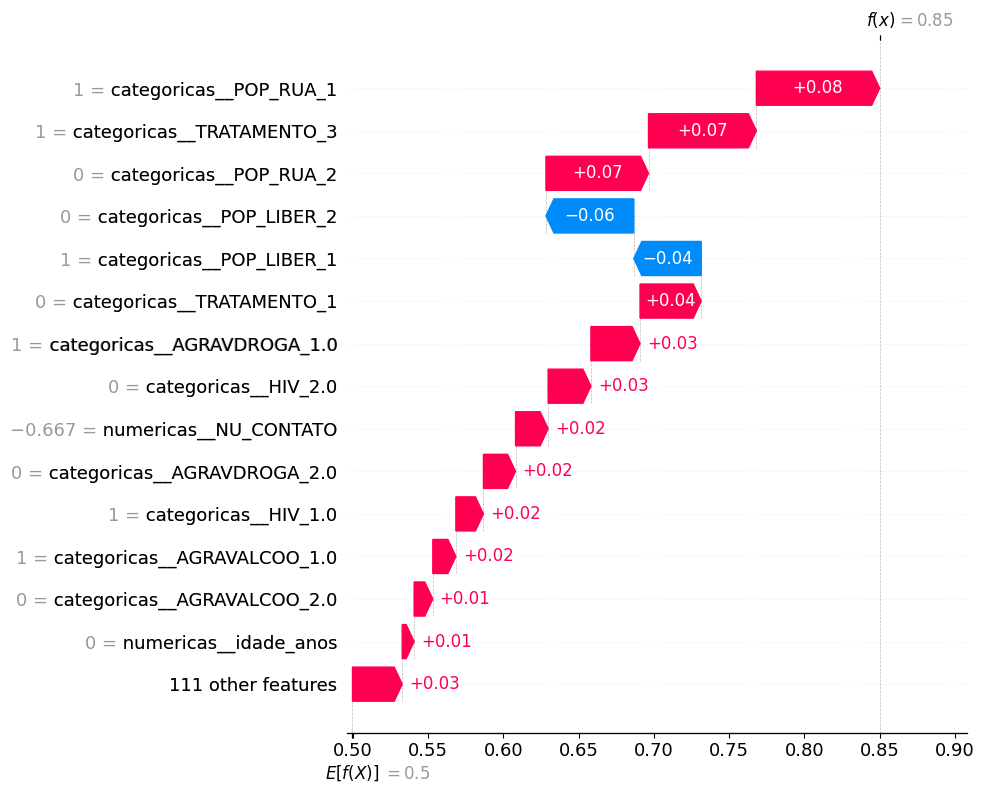

In [312]:
shap.plots.waterfall(
    explicacao,
    max_display=15
)

In [313]:
variaveis_top15 = [
    "TRATAMENTO",
    "POP_LIBER",
    "AGRAVDROGA",
    "POP_RUA",
    "AGRAVALCOO",
    "HIV",
    "NU_CONTATO",
    "RAIOX_TORA",
    "idade_val",
    "CS_ESCOL_N",
    "TPUNINOT",
    "AGRAVAIDS",
    "CS_SEXO",
    "AGRAVTABAC",
    "CS_RACA"
]

X_treino_reduzido = X_treino[variaveis_top15].copy()

X_teste1_reduzido = X_teste1[variaveis_top15].copy()

X_teste2_reduzido = X_teste2[variaveis_top15].copy()

In [314]:
colunas_categoricas_reduzidas = (
    X_treino_reduzido
    .select_dtypes(include=["object", "string"])
    .columns
    .tolist()
)

colunas_numericas_reduzidas = [
    col
    for col in X_treino_reduzido.columns
    if col not in colunas_categoricas_reduzidas
]

In [315]:
tratamento_numerico = Pipeline([
    ("preencher_mediana", SimpleImputer(strategy="median")),
    ("normalizar", RobustScaler())
])

In [316]:
tratamento_categorico = Pipeline([
    ("preencher_frequente", SimpleImputer(strategy="most_frequent")),
    ("codificar", OneHotEncoder(handle_unknown="ignore"))
])

In [317]:
pre_processamento_reduzido = ColumnTransformer([
    ("numericas",
     tratamento_numerico,
     colunas_numericas_reduzidas),

    ("categoricas",
     tratamento_categorico,
     colunas_categoricas_reduzidas)
])

In [318]:
modelo_rf_reduzido = Pipeline([
    ("pre_processamento",
     pre_processamento_reduzido),

    ("classificador",
     RandomForestClassifier(
         n_estimators=50,
         max_depth=12,
         min_samples_leaf=5,
         max_features="sqrt",
         random_state=42,
         class_weight="balanced",
         n_jobs=-1
     ))
])

In [319]:
modelo_rf_reduzido.fit(
    X_treino_reduzido,
    y_treino
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre_processamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['TRATAMENTO','POP_LIBER','AGRAVDROGA',...,'CS_SEXO','AGRAVTABAC', 'CS_RACA']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [320]:
probabilidades_rf_reduzido = (
    modelo_rf_reduzido
    .predict_proba(X_teste1_reduzido)[:,1]
)

previsoes_rf_reduzido = (
    probabilidades_rf_reduzido >= 0.50
).astype(int)

print(
    classification_report(
        y_teste1,
        previsoes_rf_reduzido
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_teste1,
        probabilidades_rf_reduzido
    )
)

              precision    recall  f1-score   support

           0       0.82      0.68      0.74       354
           1       0.66      0.81      0.73       277

    accuracy                           0.73       631
   macro avg       0.74      0.74      0.73       631
weighted avg       0.75      0.73      0.73       631

ROC-AUC: 0.8119939219645516


In [323]:
from sklearn.model_selection import RandomizedSearchCV

parametros_rf = {
    "classificador__n_estimators": [30, 50, 80],
    "classificador__max_depth": [8, 12, 15],
    "classificador__min_samples_leaf": [2, 5, 10],
    "classificador__max_features": ["sqrt"]
}

busca_rf = RandomizedSearchCV(
    estimator=modelo_rf_reduzido,
    param_distributions=parametros_rf,
    n_iter=6,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

In [324]:
busca_rf.fit(
    X_treino_reduzido,
    y_treino
)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classificador__max_depth': [8, 12, ...], 'classificador__max_features': ['sqrt'], 'classificador__min_samples_leaf': [2, 5, ...], 'classificador__n_estimators': [30, 50, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator

In [325]:
print(busca_rf.best_params_)
print(busca_rf.best_score_)

{'classificador__n_estimators': 50, 'classificador__min_samples_leaf': 5, 'classificador__max_features': 'sqrt', 'classificador__max_depth': 12}
0.7614099001130366


In [326]:
modelo_rf_otimizado = busca_rf.best_estimator_

In [327]:
probabilidades_rf_final = (
    modelo_rf_otimizado
    .predict_proba(X_teste1_reduzido)[:,1]
)

previsoes_rf_final = (
    probabilidades_rf_final >= 0.50
).astype(int)

print(classification_report(
    y_teste1,
    previsoes_rf_final
))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_teste1,
        probabilidades_rf_final
    )
)

              precision    recall  f1-score   support

           0       0.82      0.68      0.74       354
           1       0.66      0.81      0.73       277

    accuracy                           0.73       631
   macro avg       0.74      0.74      0.73       631
weighted avg       0.75      0.73      0.73       631

ROC-AUC: 0.8119939219645516


In [331]:
joblib.dump(modelo_rl, "../modelo/modelo_rl.pkl")
joblib.dump(modelo_rf, "../modelo/modelo_rf.pkl")
joblib.dump(modelo_rf_reduzido, "../modelo/modelo_rf_reduzido.pkl")

['../modelo/modelo_rf_reduzido.pkl']

In [330]:
joblib.dump(modelo_rf_reduzido, "../modelo/modelo_final.pkl")

['../modelo/modelo_final.pkl']